<a href="https://colab.research.google.com/github/pethmivithana/DL_Lab06/blob/main/Markov_Decision_Process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Markov Decision Process (MDP)

### Ransalu Senanayake

In [1]:
import copy
import timeit
import numpy as np
import matplotlib.pyplot as pl
%matplotlib inline
from ipywidgets import interactive
import ipywidgets as widgets

Create the following grid world.

**States:** A 10x10 grid

**Actions:** Up, Down, Left, Right

**Tranistion probabilities:**
* 0.7 in the direction of action
* 0.1 in the three other directions
* The robot bounces back to the same state near edges

**Rewards:**
* (7,8) has a reward +10
* (2,7) has a reward +3
* (4,3) has a reward -5
* (7,3) has a reward -10
* No reward in other states

This example is based on Decision Making Under Uncertainty by M.J. Kochenderfer.

In [2]:
#Let's define MDP paras
def createGrid10World():
    def xy2s(y, x):
        x = max(x, 0)
        y = max(y, 0)
        x = min(x, 9)
        y = min(y, 9)
        out = np.ravel_multi_index(np.array([x,y]), (10,10))
        return out

    def s2xy(s):
        x, y = np.unravel_index(s, (10,10))
        return y, x

    def gridPlot(ax, im, title='', cmap='Blues'):
        pl.imshow(im, interpolation='none', cmap=cmap, origin='lower')
        pl.colorbar()
        ax.set_xticks(np.arange(0, 10, 1));
        ax.set_yticks(np.arange(0, 10, 1));
        ax.set_xticklabels(np.arange(0, 10, 1));
        ax.set_yticklabels(np.arange(0, 10, 1));
        ax.set_xticks(np.arange(-.5, 10, 1), minor=True);
        ax.set_yticks(np.arange(-.5, 10, 1), minor=True);
        ax.grid(which='minor', color='w', linestyle='-', linewidth=1)
        pl.title(title);
        return

    A = ['left', 'right', 'up', 'down']
    S = np.arange(100)
    T = np.zeros((len(S), len(A), len(S)))
    R = np.zeros((len(S), len(A)))
    for s in S:
        x, y = s2xy(s)
        if x == 2 and y == 7:
            R[s, :] = 3
        elif x == 7 and y == 8:
            R[s, :] = 10
        else:
            if x == 7 and y == 3:
                R[s, :] = -10
            elif x == 4 and y == 3:
                R[s, :] = -5
            elif x == 0:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 0] = -0.7
            elif x == 9:
                if y == 0 or y == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 1] = -0.7
            elif y == 0:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 3] = -0.7
            elif y == 9:
                if x == 0 or x == 9:
                    R[s, :] = -0.2
                else:
                    R[s, :] = -0.1
                R[s, 2] = -0.7

            for a in A:
                if a == 'left':
                    T[s, 0, xy2s(x - 1, y)] += 0.7
                    T[s, 0, xy2s(x + 1, y)] += 0.1
                    T[s, 0, xy2s(x, y - 1)] += 0.1
                    T[s, 0, xy2s(x, y + 1)] += 0.1
                elif a == 'right':
                    T[s, 1, xy2s(x + 1, y)] += 0.7
                    T[s, 1, xy2s(x - 1, y)] += 0.1
                    T[s, 1, xy2s(x, y - 1)] += 0.1
                    T[s, 1, xy2s(x, y + 1)] += 0.1
                elif a == 'up':
                    T[s, 2, xy2s(x, y + 1)] += 0.7
                    T[s, 2, xy2s(x, y - 1)] += 0.1
                    T[s, 2, xy2s(x - 1, y)] += 0.1
                    T[s, 2, xy2s(x + 1, y)] += 0.1
                elif a == 'down':
                    T[s, 3, xy2s(x, y - 1)] += 0.7
                    T[s, 3, xy2s(x, y + 1)] += 0.1
                    T[s, 3, xy2s(x - 1, y)] += 0.1
                    T[s, 3, xy2s(x + 1, y)] += 0.1

    for a, c_x, c_y in [(0,0,0), (0,0,9),(1,9,0),(1,9,9),(2,0,9),(2,9,9),(3,0,0),(3,9,0)]:
        R[xy2s(c_x,c_y),a] = -0.8

    discount = 0.9

    nextStates = {}
    for si in range(len(S)):
        for ai in range(len(A)):
            nextStates[(si,ai)] = np.where((T[si, ai, :] != 0) == True)[0]

    return {'S':S, 'A':A, 'T':T, 'R':R, 'discount':discount, 'nextStates':nextStates, 'gridPlot':gridPlot, 'xy2s':xy2s, 's2xy':s2xy}

In [3]:
class MDP():
    def __init__(self):
        pass

    def inbuilt_init(self, mdp_dict):
        self.S = mdp_dict['S']
        self.A = mdp_dict['A']
        self.T = mdp_dict['T']
        self.R = mdp_dict['R']
        self.discount = mdp_dict['discount']
        self.nextStates = mdp_dict['nextStates']
        self.gridPlot = mdp_dict['gridPlot']
        self.xy2s = mdp_dict['xy2s']
        self.s2xy = mdp_dict['s2xy']

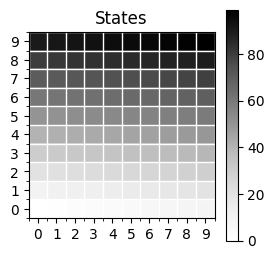

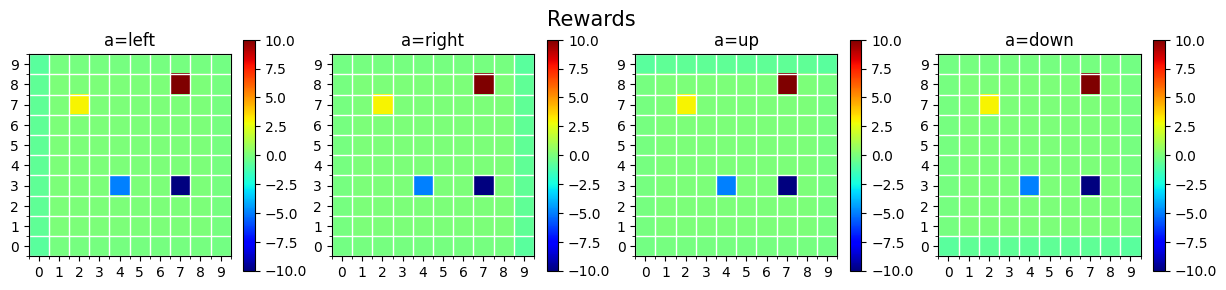

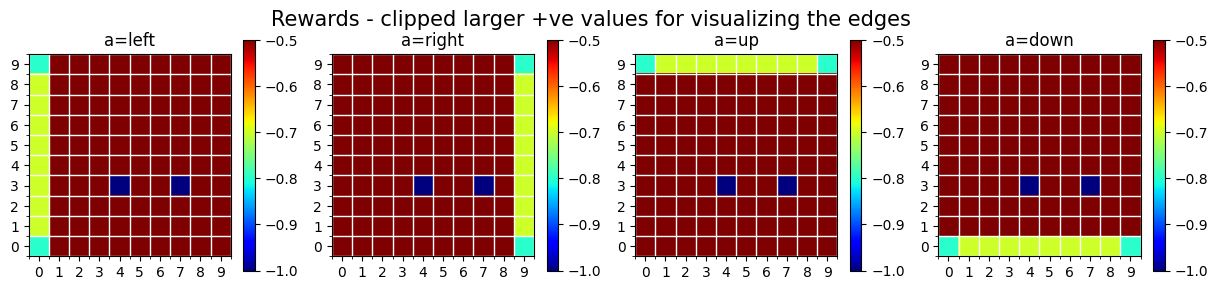

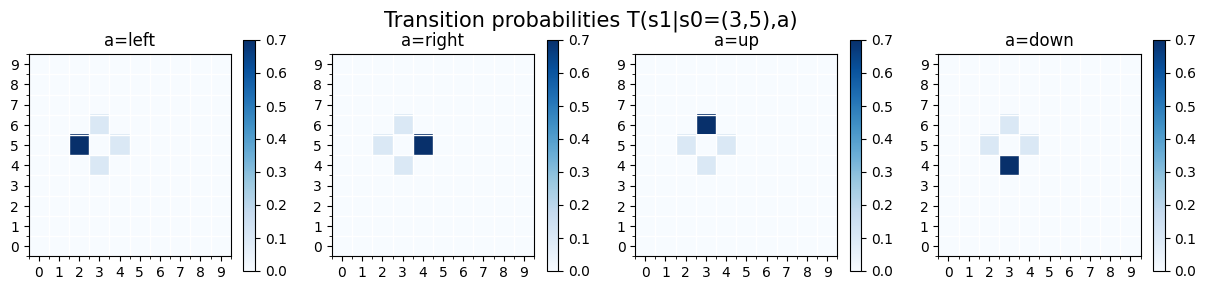

In [4]:
#Define the MDP
mdp = MDP()
mdp.inbuilt_init(mdp_dict=createGrid10World())

#Plot states
pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=mdp.S.reshape((10,10)), title='States', cmap='Greys')

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.R[:,a].reshape((10,10)), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
pl.figure(figsize=(15,3))
pl.suptitle('Rewards - clipped larger +ve values for visualizing the edges', fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=np.clip(mdp.R[:,a].reshape((10,10)), -1, -0.5), title='a='+mdp.A[a], cmap='jet')
pl.show()

#Plot rewards
s0_x, s0_y = 3, 5
s0 = mdp.xy2s(s0_x, s0_y)
pl.figure(figsize=(15,3))
pl.suptitle('Transition probabilities T(s1|s0=({},{}),a)'.format(s0_x, s0_y), fontsize=15)
for a in range(4):
    pl.subplot(1,4,a+1)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title='a='+mdp.A[a], cmap='Blues')
pl.show()

In [5]:
#An interactive plot of transition probabilities
def f(s0_x, s0_y, action):
    a = mdp.A.index(action)
    s0 = mdp.xy2s(int(s0_x), int(s0_y))
    pl.figure(figsize=(6,6))
    title = 'Transition probabilities T(s1|s0=({},{}),a={})'.format(int(s0_x),int(s0_y),action)
    mdp.gridPlot(ax=pl.gca(), im=mdp.T[s0,a,:].reshape((10,10)), title=title, cmap='Blues')
    pl.show()

interactive_plot = interactive(f, s0_x='4', s0_y='5', action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']))
interactive_plot

interactive(children=(Text(value='4', description='s0_x'), Text(value='5', description='s0_y'), ToggleButtons(…

### 1. Policy evaluation

Computing the utility, U.

$U^\pi_k(s) = R(s, \pi(s)) + \gamma \sum_{s'} T(s' \mid s, \pi(s))U^\pi_{k-1}(s')$

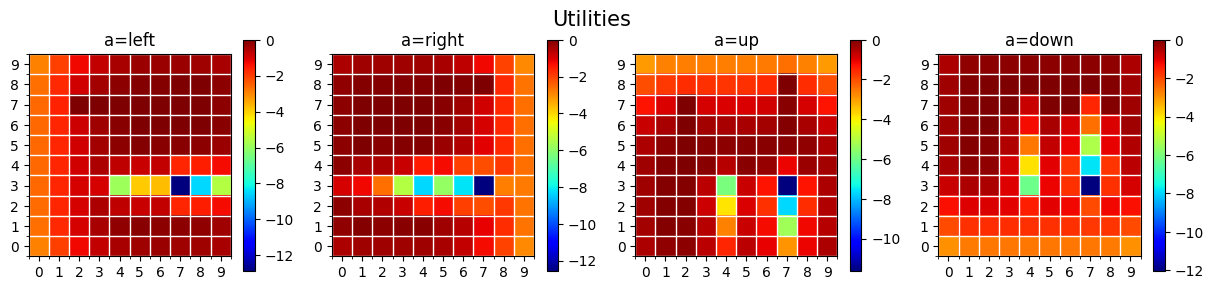

In [13]:
def iterativePolicyEvaluation(mdp, policy, numIterations=10, gamma=0.9):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)

#type your code here
    for t in range(numIterations):
        U_old = copy.copy(U)
        for s in mdp.S:
            if isinstance(policy, int):   # fixed single action
                a = policy
            else:                         # mapping state -> action
                a = policy[s]

            total = 0
            # iterate over all possible next states
            for s1 in mdp.S:
                prob = mdp.T[s, a, s1]       # transition probability
                r = mdp.R[s, a]              # reward depends only on (s, a)
                total += prob * (r + gamma * U_old[s1])

            U[s] = total
    return U


# -----------------------------
# Run for all 4 actions
# -----------------------------
numIterations = 5
pl.figure(figsize=(15,3))
pl.suptitle('Utilities', fontsize=15)

for a in range(4):
    pl.subplot(1,4,a+1)
    U = iterativePolicyEvaluation(mdp=mdp, policy=a, numIterations=numIterations)
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='a='+mdp.A[a], cmap='jet')

pl.show()

# Optional: print utilities
# print(np.round(U.reshape(10,10),3))

In [14]:
def f(action, numIter=1):
    U = iterativePolicyEvaluation(mdp, policy=mdp.A.index(action), numIterations=numIter)
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    pl.show()

interactive_plot = interactive(f, action=widgets.ToggleButtons(options=['left', 'right', 'up', 'down']),
                               numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(ToggleButtons(description='action', options=('left', 'right', 'up', 'down'), value='left…

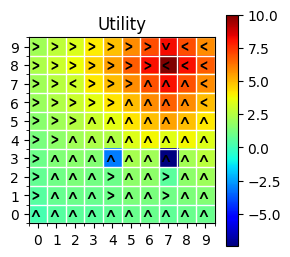

In [15]:
# Value Iteration
def valueIteration(mdp, numIterations=1, gamma=0.9):
    U = np.zeros(len(mdp.S))
    U_old = copy.copy(U)
    for t in range(numIterations):
        U_old = copy.copy(U)
        for s in mdp.S:
            # type your code here
            # Bellman Optimality update
            U[s] = max([
                mdp.R[s, a] + gamma * sum([mdp.T[s, a, s1] * U_old[s1] for s1 in mdp.S])
                for a in range(len(mdp.A))
            ])
    return U


# Policy Extraction from Utility values
def policyExtration(mdp, U, gamma=0.9):
    policy = np.zeros(len(mdp.S))
    for s in mdp.S:
        # type your code here
        # Choose the action that maximizes expected return
        q_values = [
            mdp.R[s, a] + gamma * sum([mdp.T[s, a, s1] * U[s1] for s1 in mdp.S])
            for a in range(len(mdp.A))
        ]
        policy[s] = np.argmax(q_values)
    return policy


# -----------------------------
# Run Value Iteration + Policy Extraction
# -----------------------------
U = valueIteration(mdp, numIterations=20)   # increased iterations for convergence
policy = policyExtration(mdp, U=U)

pl.figure(figsize=(3,3))
mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')

# Draw policy arrows
for s in range(100):
    x, y = mdp.s2xy(s)
    if policy[s] == 0:
        m = '\u02C2'   # left
    elif policy[s] == 1:
        m = '\u02C3'   # right
    elif policy[s] == 2:
        m = '\u02C4'   # up
    elif policy[s] == 3:
        m = '\u02C5'   # down
    pl.text(x-0.5, y-1, m, color='k', size=20)

pl.show()

In [16]:
def f(numIter=1):
    start_time = timeit.default_timer()
    U = valueIteration(mdp, numIterations=numIter)
    policy = policyExtration(mdp, U=U)
    elapsed = timeit.default_timer() - start_time
    print('time=', np.round(elapsed*1000,2))
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=U.reshape(10,10), title='Utility', cmap='jet')
    for s in range(100):
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m='\u02C2'
        elif policy[s] == 1:
            m='\u02C3'
        elif policy[s] == 2:
            m='\u02C4'
        elif policy[s] == 3:
            m='\u02C5'
        pl.text(x-0.5,y-1,m,color='k',size=20)
    pl.show()

interactive_plot = interactive(f, numIter=widgets.IntSlider(min=0, max=20, step=1, value=0))
interactive_plot

interactive(children=(IntSlider(value=0, description='numIter', max=20), Output()), _dom_classes=('widget-inte…

### 2. Policy iteration

Policy evaluation can be used in policy iteration:
1. Given the current policy, compute U
2. Using U, compute a new policy

In [17]:
def policyIteration(mdp, numIterations=1, gamma=0.9, evalIterations=10):
    U_pi_k = np.zeros(len(mdp.S)) # initial values
    pi_k = np.random.randint(low=0, high=len(mdp.A), size=len(mdp.S), dtype=int) # initial policy
    pi_kp1 = copy.copy(pi_k)

    for t in range(numIterations):
        # -------------------
        # Policy Evaluation: compute U_pi_k
        # -------------------
        for _ in range(evalIterations):  # iterative policy evaluation
            U_old = copy.copy(U_pi_k)
            for s in mdp.S:
                a = pi_k[s]
                U_pi_k[s] = mdp.R[s, a] + gamma * sum([
                    mdp.T[s, a, s1] * U_old[s1] for s1 in mdp.S
                ])

        # -------------------
        # Policy Improvement
        # -------------------
        for s in mdp.S:
            q_values = [
                mdp.R[s, a] + gamma * sum([
                    mdp.T[s, a, s1] * U_pi_k[s1] for s1 in mdp.S
                ]) for a in range(len(mdp.A))
            ]
            pi_kp1[s] = np.argmax(q_values)

        # if policy stable, stop
        if np.array_equal(pi_k, pi_kp1):
            break
        pi_k = copy.copy(pi_kp1)

    return U_pi_k, pi_kp1


# -----------------------------
# Run Policy Iteration
# -----------------------------
U_pi_k, pi_kp1 = policyIteration(mdp, numIterations=10)

print("Final Utilities:", U_pi_k.reshape(10,10))
print("Final Policy:", pi_kp1.reshape(10,10))

Final Utilities: [[ 0.40812576  0.73469101  0.86445298  0.8358841   0.91309512  1.09820981
   1.06317208  0.92346476  1.09050278  1.07480862]
 [ 0.74395326  1.03833371  1.18314508  1.11226329  1.20143965  1.46274567
   1.40564462  1.18496671  1.44844071  1.56063523]
 [ 0.95809655  1.26801482  1.4473634   1.3054969   1.08498461  1.79252772
   1.70106505  0.69816903  1.75110025  2.05251938]
 [ 1.17925566  1.52082484  1.76078605  1.55158269 -2.99902168  2.23831897
   2.14349205 -7.38628172  2.17965076  2.65037634]
 [ 1.43128027  1.81290027  2.14923925  2.45323784  2.47974987  3.41903728
   3.89478378  3.43143066  3.88616437  3.38245637]
 [ 1.71365182  2.14670447  2.55051583  3.01109473  3.52565092  4.19663694
   4.89734637  5.39033472  4.8837241   4.11070915]
 [ 1.97994532  2.47219994  2.96549307  3.56103285  4.21234639  4.96961027
   5.84760081  6.66858691  5.83948478  4.91553836]
 [ 2.11157261  2.58381722  3.          4.10402578  4.92989923  5.85161556
   6.9196857   8.14542715  6.91647

In [19]:
def f(numIter=1):
    start_time = timeit.default_timer()

    # code you want to evaluate: run policy iteration
    value, policy = policyIteration(mdp, numIterations=numIter)

    elapsed = timeit.default_timer() - start_time
    print('time =', np.round(elapsed*1000, 2), "ms")

    # plot utilities and policy
    pl.figure(figsize=(3,3))
    mdp.gridPlot(ax=pl.gca(), im=value.reshape(10,10), title=f'Policy Iteration (iter={numIter})', cmap='jet')

    for s in range(len(mdp.S)):   # safer than hardcoding 100
        x, y = mdp.s2xy(s)
        if policy[s] == 0:
            m = '\u02C2'   # left
        elif policy[s] == 1:
            m = '\u02C3'   # right
        elif policy[s] == 2:
            m = '\u02C4'   # up
        elif policy[s] == 3:
            m = '\u02C5'   # down
        pl.text(x-0.5, y-1, m, color='k', size=20)

    pl.show()


# Interactive slider for numIter
interactive_plot = interactive(
    f,
    numIter=widgets.IntSlider(min=0, max=20, step=1, value=0, description="Iterations")
)
interactive_plot

interactive(children=(IntSlider(value=0, description='Iterations', max=20), Output()), _dom_classes=('widget-i…

🔹 Model-Based RL

The agent has (or learns) a model of the environment:

Transition function
𝑃
(
𝑠
′
∣
𝑠
,
𝑎
)
P(s
′
∣s,a): probability of going to next state.

Reward function
𝑅
(
𝑠
,
𝑎
)
R(s,a): expected reward.

Uses this model to simulate outcomes, plan ahead, and compute optimal policy.

Examples: Value Iteration, Policy Iteration, Dynamic Programming.

Pros: More sample-efficient (can “think” using the model).

Cons: Requires accurate model; hard in complex/unknown environments.

🔹 Model-Free RL

The agent does not know the environment model.

Learns value functions or policies directly from interaction/experience.

Examples: Q-Learning, SARSA, Policy Gradient, Deep Q-Networks (DQN).

Pros: Works even when model is unknown or very complex.

Cons: Needs more data and exploration; less sample-efficient.

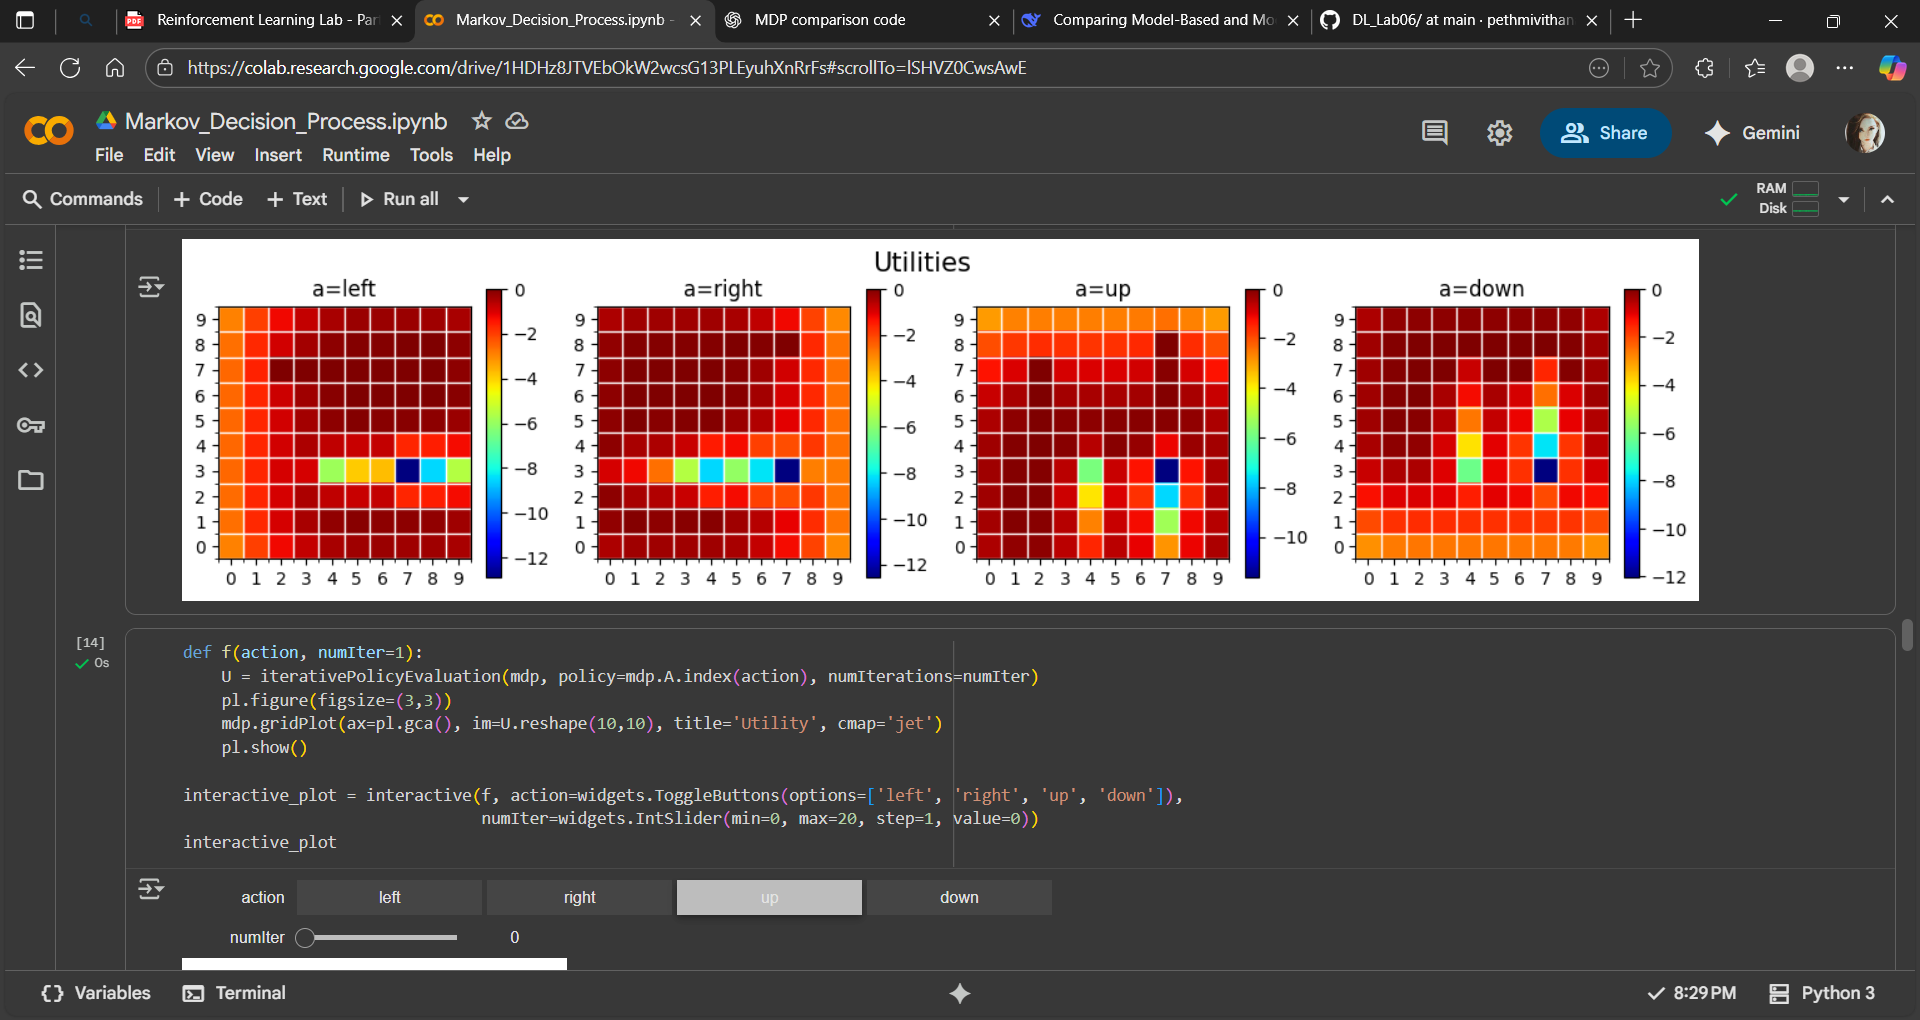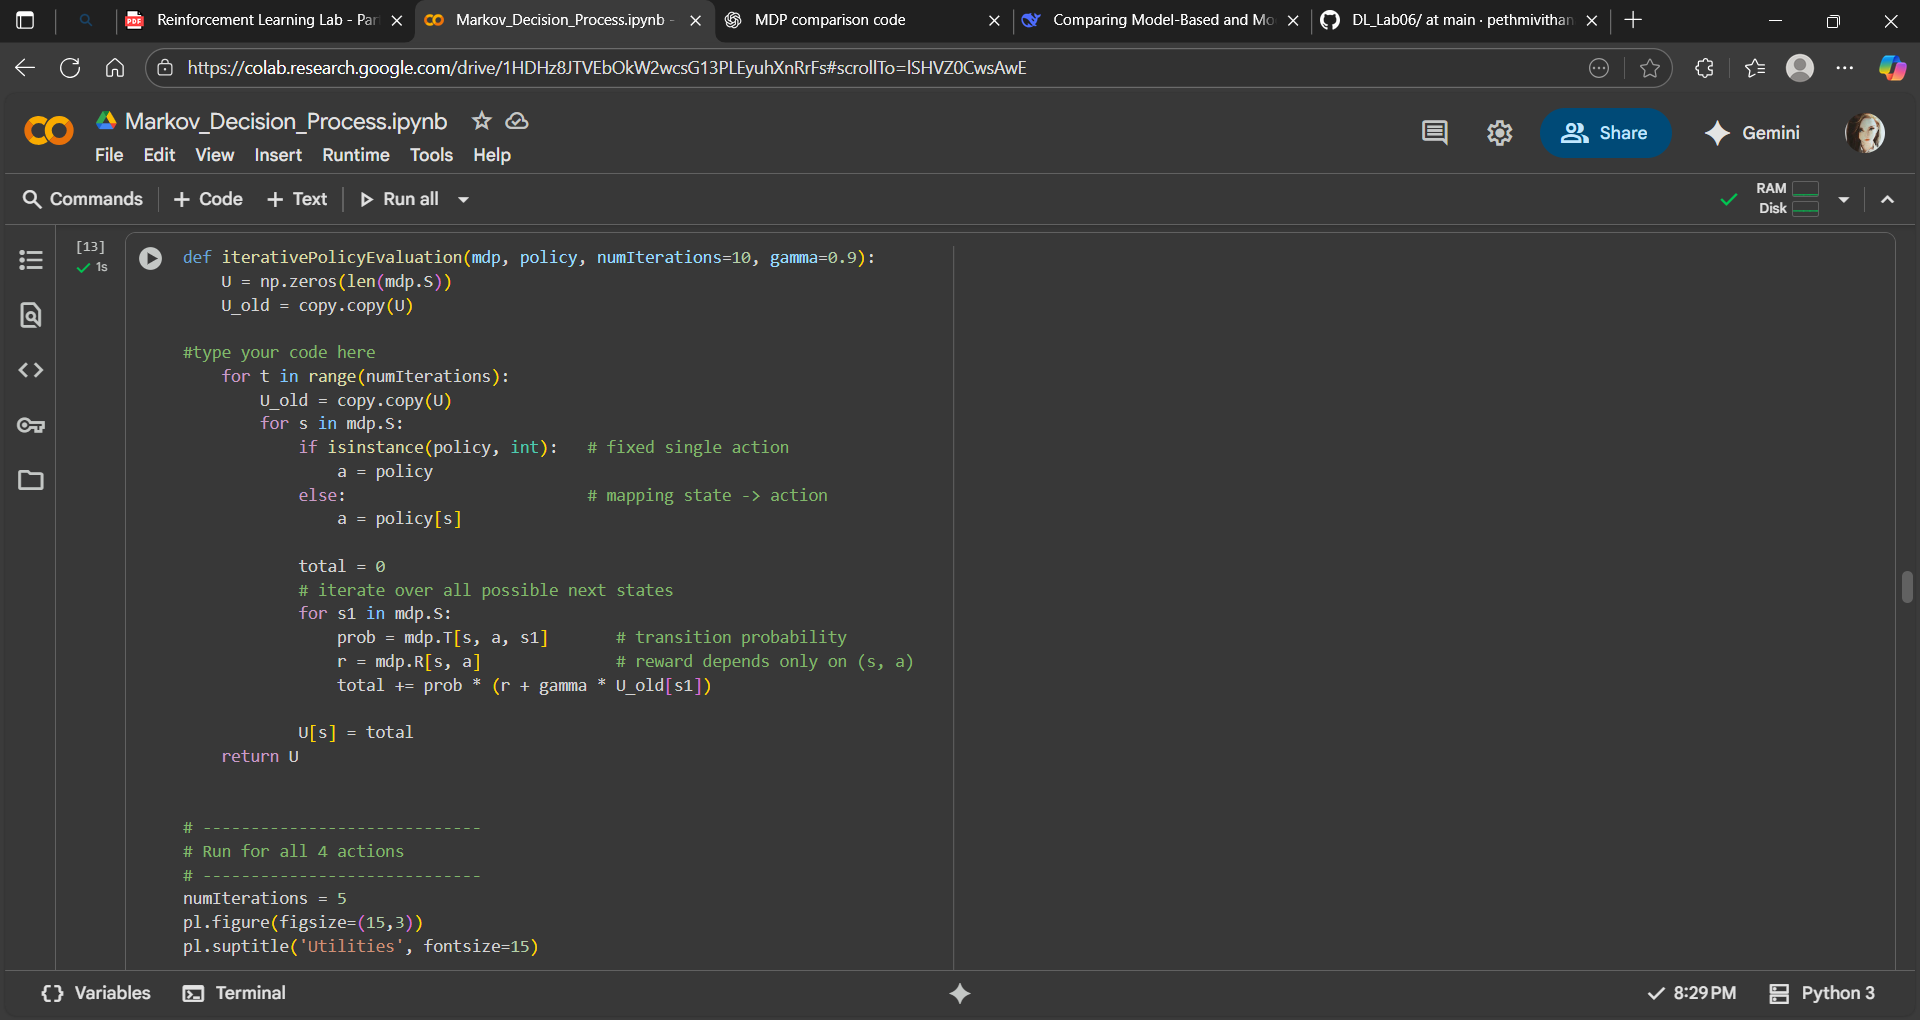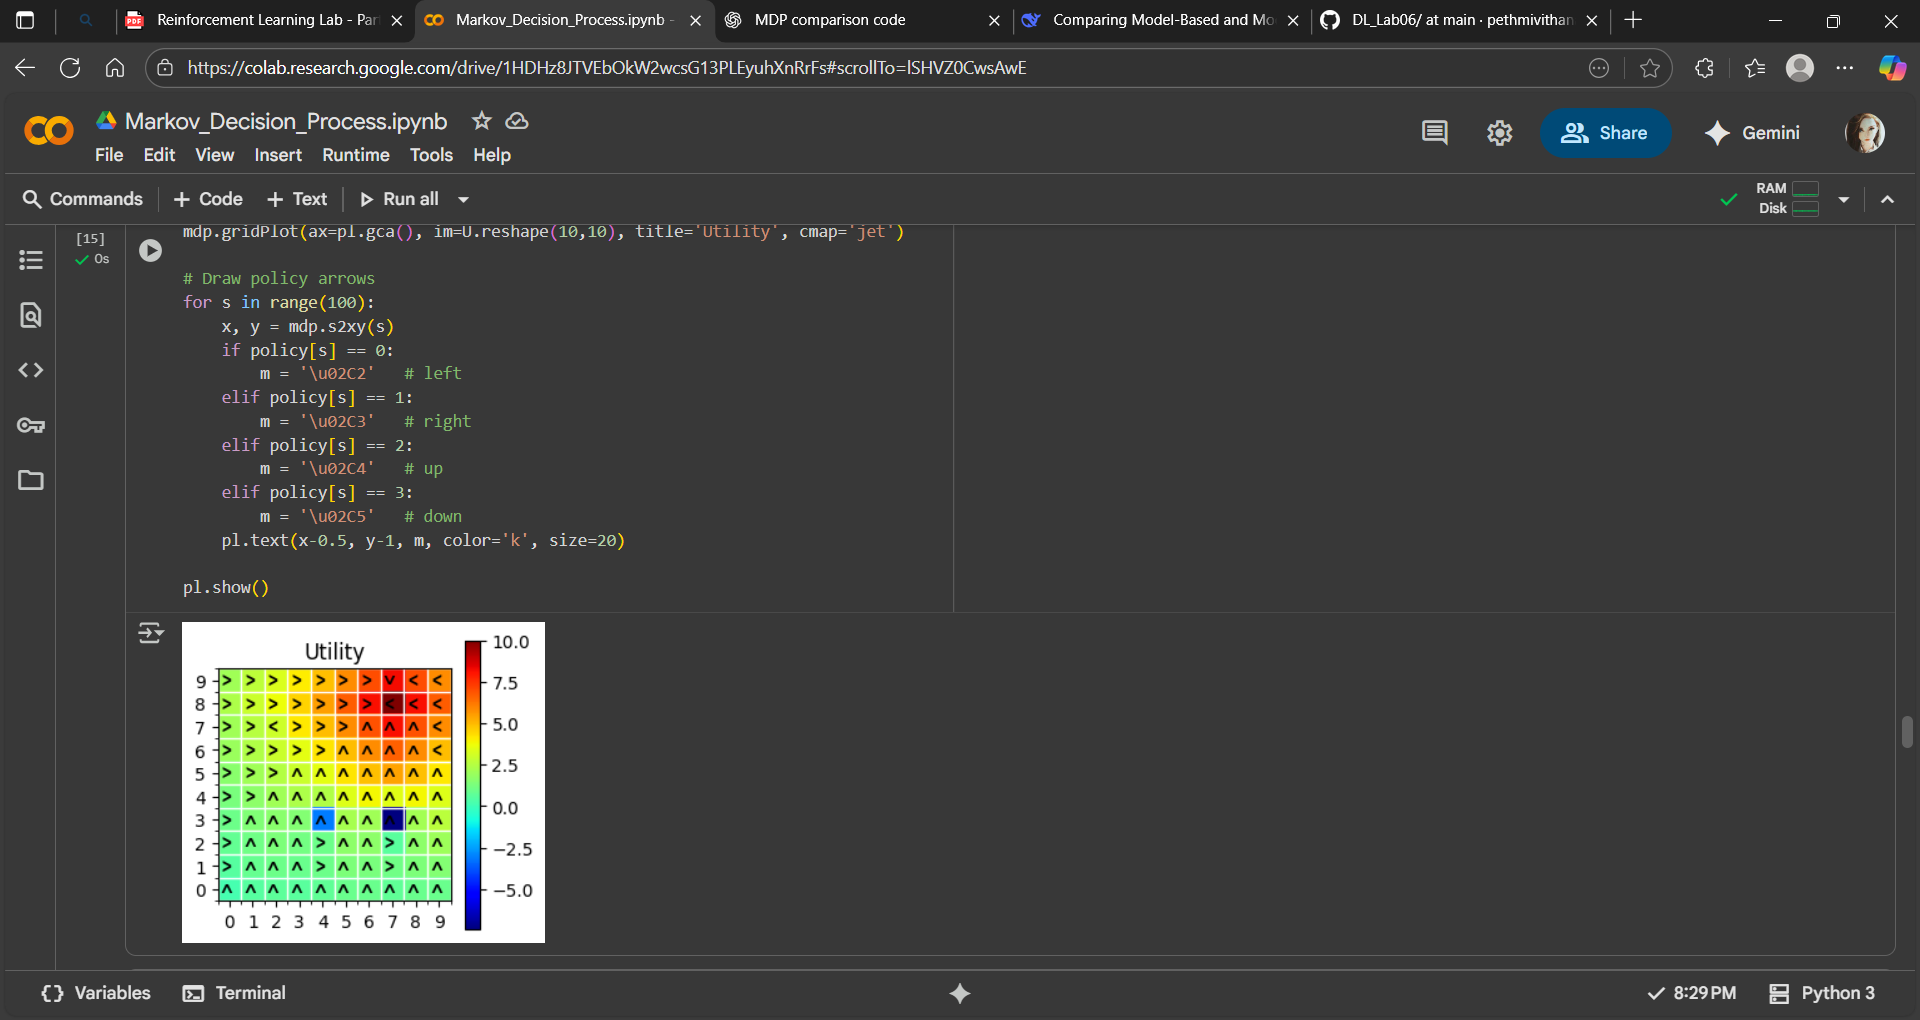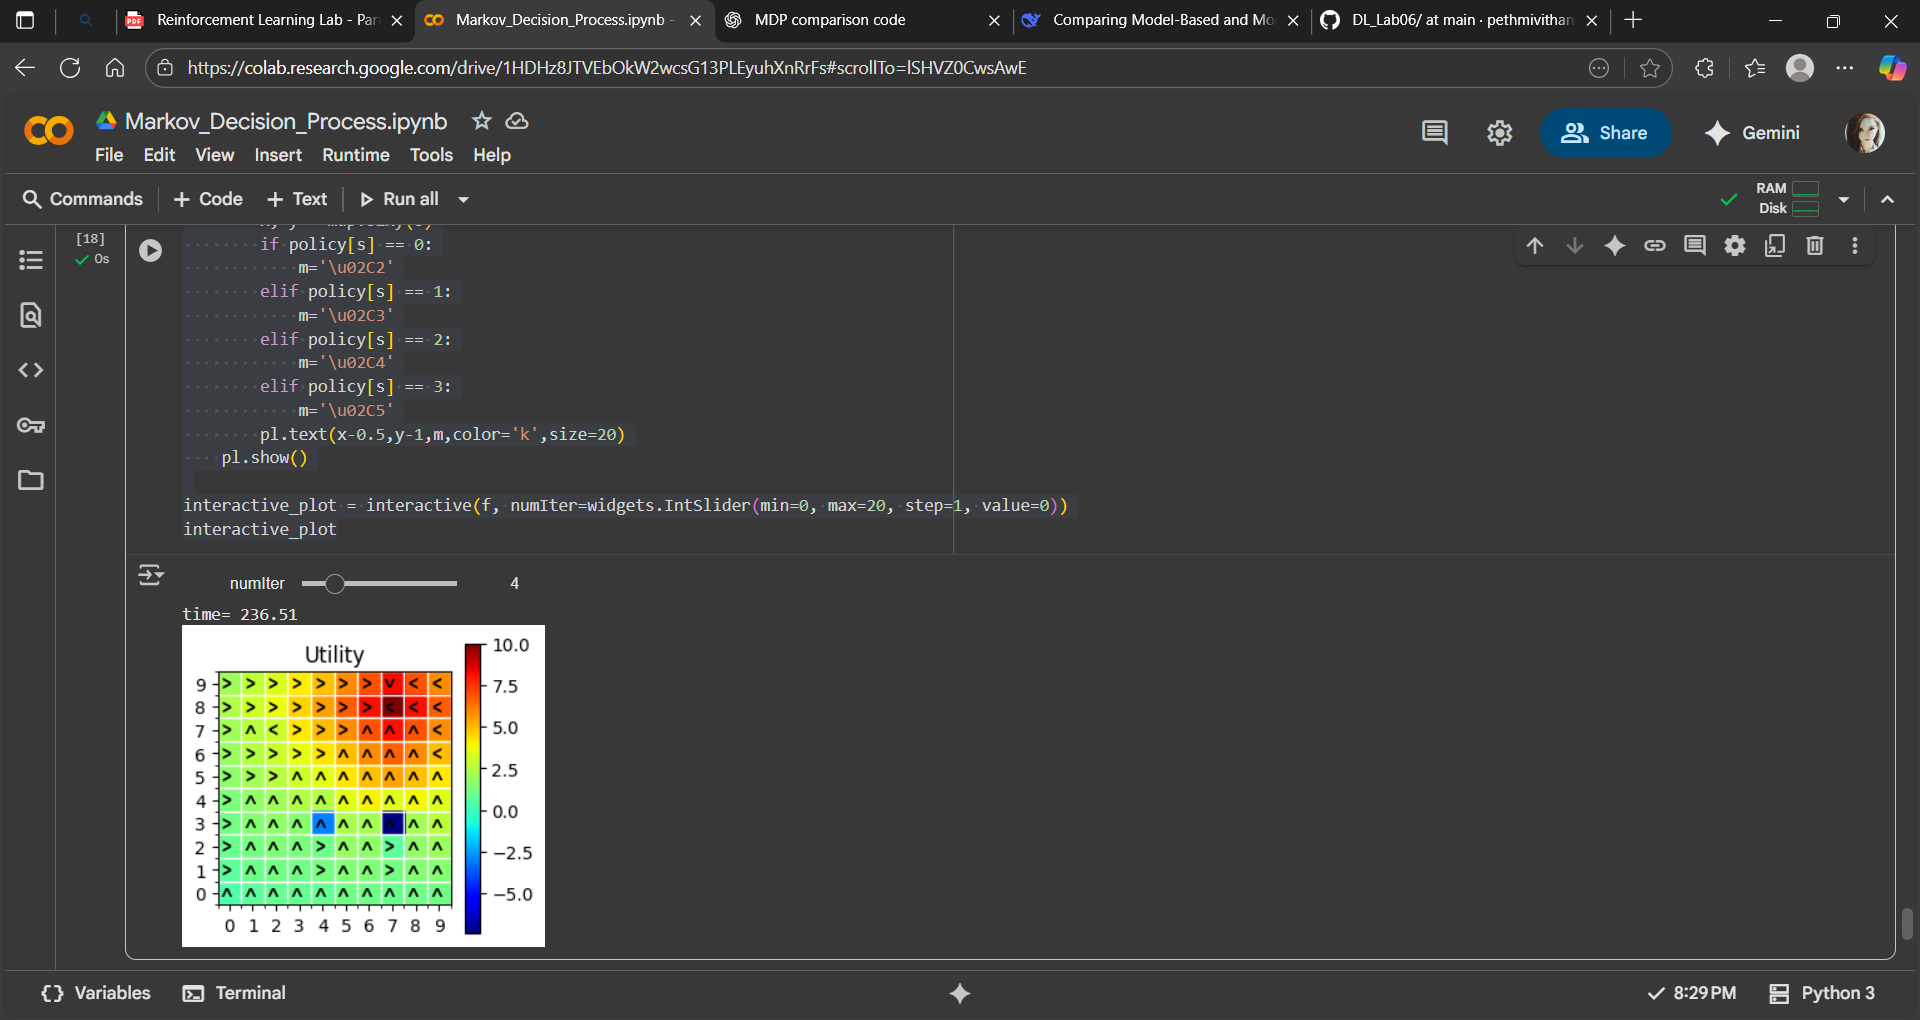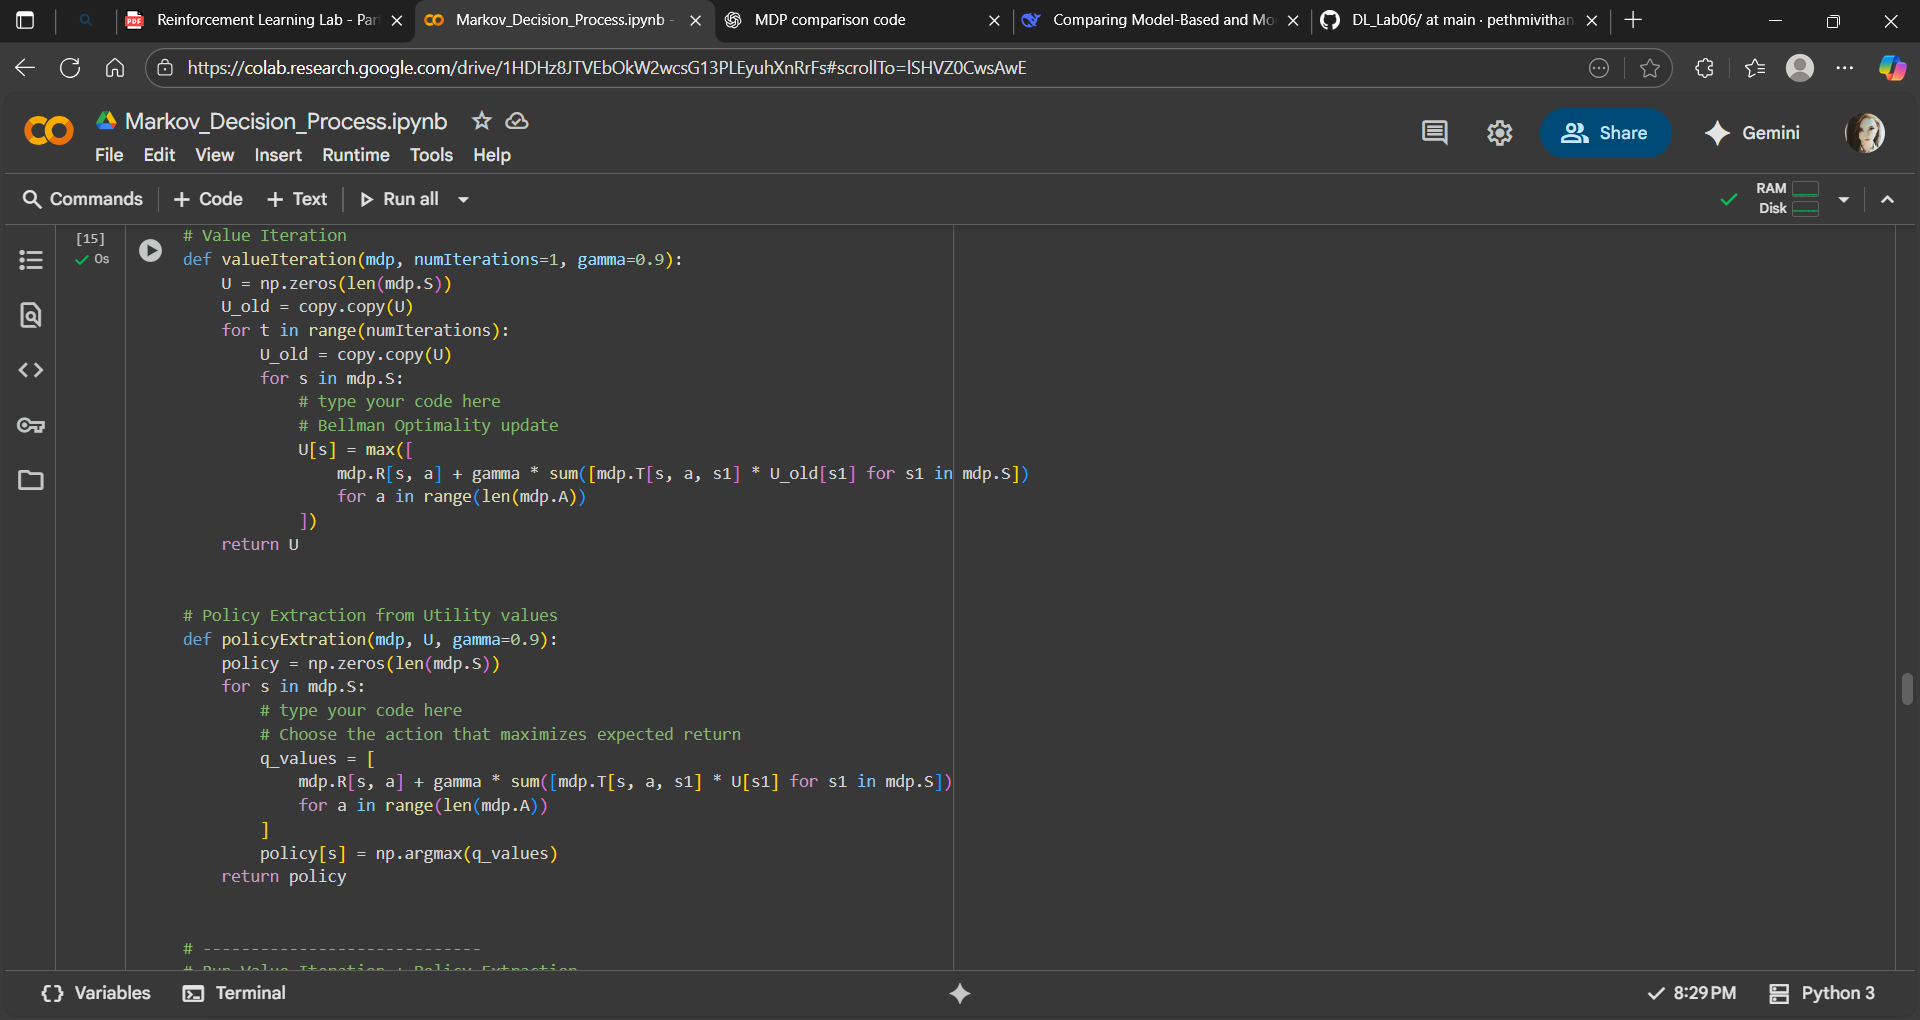